# SeoulEVCheck — 1주차 ML
## 서울 전기차 충전 수요 예측 (XGBoost)
담당: 오영석 · 데이터: 한국전력공사 서울 충전량(약 63만 세션)

구·충전소 단위 **일별 충전량**을 예측하고, 수요 핫스팟(배달충전 우선지역)을 도출한다.

In [1]:
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
%matplotlib inline
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False

## 1. 데이터 로드

In [2]:
df = pd.read_excel('../data/한국전력공사_서울시 전기차 충전소 충전량_20220331.xlsx')
print(df.shape)
df.head()

(638702, 9)


,충전구분,충전소명,주소,충전기용량,충전량,충전시간,충전분,충전시작시각,충전종료시각
0,급속,영등포전력지사,서울특별시 영등포구 경인로 878,50,0.05,0,0,2021-01-01 02:06:20,2021-01-01 02:06:36
1,급속,영등포전력지사,서울특별시 영등포구 경인로 878,50,13.10,0,29,2021-01-02 14:58:37,2021-01-02 15:28:25
2,급속,영등포전력지사,서울특별시 영등포구 경인로 878,50,47.56,1,33,2021-01-02 20:57:53,2021-01-02 22:31:46
3,급속,영등포전력지사,서울특별시 영등포구 경인로 878,50,24.77,0,38,2021-01-04 12:12:02,2021-01-04 12:51:01
4,급속,영등포전력지사,서울특별시 영등포구 경인로 878,50,19.21,0,29,2021-01-04 22:51:11,2021-01-04 23:21:04


## 2. 전처리
주소→구 추출(도로명/지번 혼재 대응) · 날짜 파싱 · null/음수 제거 · 밀집 구간 필터

In [3]:
def extract_gu(a):
    if not isinstance(a,str): return None
    for t in a.split():
        if t.endswith('구'): return t
    return None
df['start']=pd.to_datetime(df['충전시작시각'],errors='coerce')
df['gu']=df['주소'].map(extract_gu)
df['충전량']=pd.to_numeric(df['충전량'],errors='coerce')
n0=len(df)
df=df.dropna(subset=['start','gu','충전량']); df=df[df['충전량']>=0]
df['ym']=df['start'].dt.to_period('M'); c=df['ym'].value_counts()
df=df[df['ym'].isin(c[c>=c.max()*0.10].index)].copy()
df['date']=df['start'].dt.date; df['weekday']=df['start'].dt.weekday; df['month']=df['start'].dt.month
print('원본', n0, '-> 정제후', len(df))
print('기간', df['date'].min(), '~', df['date'].max(), '| 구', df['gu'].nunique())

원본 638702 -> 정제후 627301
기간 2021-01-01 ~ 2022-03-31 | 구 25


## 3. EDA — 분포·충전구분·수요 상위 구

수요 TOP5 구


gu
송파구    1473118.0
강남구    1415600.0
마포구     938253.0
서초구     818852.0
용산구     780632.0
Name: 충전량, dtype: float64


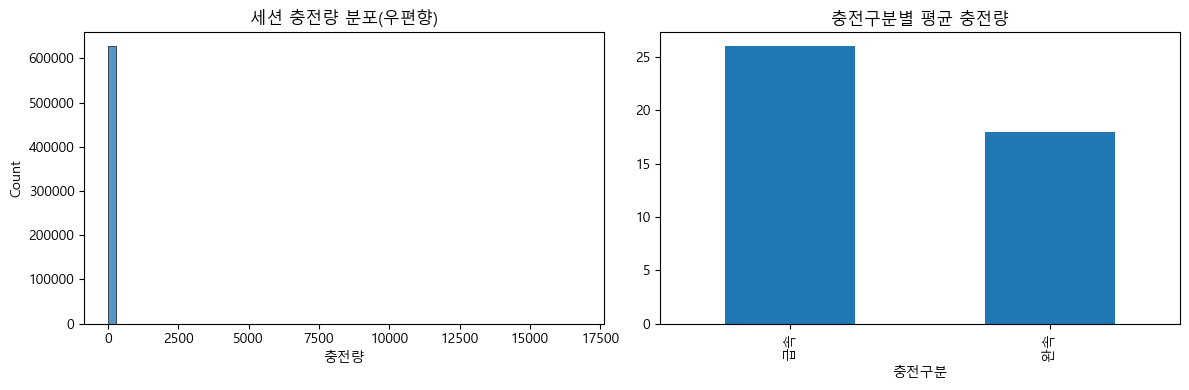

In [4]:
print('수요 TOP5 구')
print(df.groupby('gu')['충전량'].sum().sort_values(ascending=False).head().round(0))
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['충전량'],bins=60,ax=ax[0]); ax[0].set_title('세션 충전량 분포(우편향)')
df.groupby('충전구분')['충전량'].mean().plot(kind='bar',ax=ax[1]); ax[1].set_title('충전구분별 평균 충전량')
plt.tight_layout(); plt.show()

## 4. 집계 (구 / 충전소 단위)

In [5]:
gu=(df.groupby(['gu','충전구분','date'],as_index=False)
      .agg(충전량=('충전량','sum'),weekday=('weekday','first'),month=('month','first')))
st=(df.groupby(['충전소명','gu','충전구분','충전기용량','date'],as_index=False)
      .agg(충전량=('충전량','sum'),weekday=('weekday','first'),month=('month','first')))
print('gu_day',gu.shape,'| station_day',st.shape)

gu_day (22583, 6) | station_day (217946, 8)


## 5. 모델링 — 베이스라인 vs XGBoost
타깃: 일별 충전량 · 누수 특성(세션수·충전시간) 제외 · 범주형 원-핫

In [6]:
def baseline(tr,te,keys):
    gm=tr.groupby(keys,as_index=False)['충전량'].mean().rename(columns={'충전량':'p'})
    m=te.merge(gm,on=keys,how='left'); m['p']=m['p'].fillna(tr['충전량'].mean())
    return r2_score(te['충전량'],m['p'])
def train(d,cats,nums,keys,name):
    X=pd.concat([pd.get_dummies(d[cats].astype(str),dtype=np.uint8).reset_index(drop=True),
                 d[nums].reset_index(drop=True)],axis=1); y=d['충전량'].values
    Xtr,Xte,ytr,yte,dtr,dte=train_test_split(X,y,d,test_size=0.2,random_state=42)
    b=baseline(dtr,dte,keys)
    m=xgb.XGBRegressor(n_estimators=400,max_depth=7,learning_rate=0.08,subsample=0.8,
        colsample_bytree=0.8,tree_method='hist',random_state=42).fit(Xtr,ytr)
    p=m.predict(Xte); r2=r2_score(yte,p); rmse=mean_squared_error(yte,p)**0.5
    cv=cross_val_score(m,X,y,cv=KFold(5,shuffle=True,random_state=42),scoring='r2')
    print(name, 'baseline R2=%.3f'%b, '| XGB R2=%.3f RMSE=%.0f'%(r2,rmse), '| CV R2=%.3f'%cv.mean())
    return m,Xte,yte,p
mg,Xg,yg,pg=train(gu,['gu','충전구분'],['weekday','month'],['gu','충전구분','weekday'],'[구]')
ms,Xs,ys,ps=train(st,['충전소명','gu','충전구분'],['충전기용량','weekday','month'],['충전소명','weekday'],'[충전소]')

[구] baseline R2=0.761 | XGB R2=0.787 RMSE=216 | CV R2=0.768


[충전소] baseline R2=0.485 | XGB R2=0.571 RMSE=52 | CV R2=0.570


## 6. 예측 vs 실제 · 특성 중요도 (구 모델)

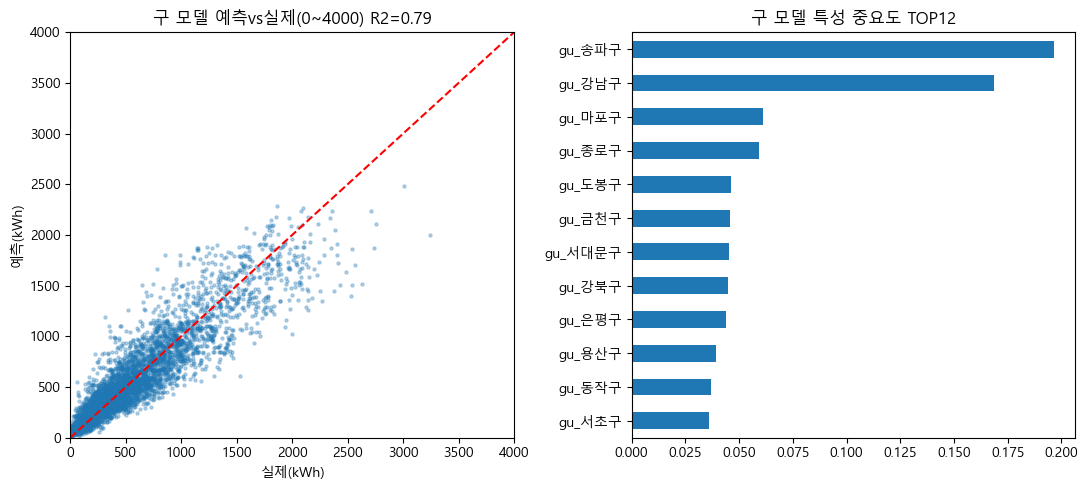

In [7]:
fig,ax=plt.subplots(1,2,figsize=(11,5))
ax[0].scatter(yg,pg,s=5,alpha=0.3); ax[0].plot([0,4000],[0,4000],'r--')
ax[0].set_xlim(0,4000); ax[0].set_ylim(0,4000)
ax[0].set_title('구 모델 예측vs실제(0~4000) R2=%.2f'%r2_score(yg,pg)); ax[0].set_xlabel('실제(kWh)'); ax[0].set_ylabel('예측(kWh)')
pd.Series(mg.feature_importances_,index=Xg.columns).sort_values().tail(12).plot(kind='barh',ax=ax[1])
ax[1].set_title('구 모델 특성 중요도 TOP12'); plt.tight_layout(); plt.show()

## 7. 결론 및 향후
- 구 모델 R²≈0.79, 충전소 모델 R²≈0.57 — **두 모델 모두 베이스라인 초과**
- 수요 핫스팟(송파·강남·마포…) → 배달충전 우선지역
- 향후: year 추세 특성 / 2주 DL(LSTM 시계열) / 3주 LLM(충전 어드바이저·RAG)

In [8]:
joblib.dump(mg,'../models/xgb_gu.pkl'); joblib.dump(ms,'../models/xgb_station.pkl')
print('모델 저장 완료')

모델 저장 완료
